In [8]:
import networkx as nx
import random
import warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [9]:
interval_labeling = pd.read_csv("../data/csv/intervalli_glucosio.csv", delimiter=',')
df = pd.DataFrame(interval_labeling)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])
df["duration"] = ((df["end_time"] - df["start_time"]).dt.total_seconds() / 60).round(2)
df

,symbol,start_time,end_time,label,duration
0,b,2024-08-26 00:00:29,2024-08-26 01:40:29,high,100.00
1,c,2024-08-26 01:45:29,2024-08-26 07:55:29,normal,370.00
2,b,2024-08-26 08:00:29,2024-08-26 10:20:28,high,139.98
3,a,2024-08-26 10:25:28,2024-08-26 10:50:29,extremely_high,25.02
4,b,2024-08-26 10:55:28,2024-08-26 11:00:28,high,5.00
...,...,...,...,...,...
205,c,2024-09-08 10:41:33,2024-09-08 11:16:33,normal,35.00
206,d,2024-09-08 11:21:33,2024-09-08 11:36:32,low,14.98
207,e,2024-09-08 11:41:32,2024-09-08 11:51:33,extremely_low,10.02
208,d,2024-09-08 11:56:33,2024-09-08 11:56:33,low,0.00


 ## GRAFO CON AUTOMA DETERMINISTICO


In [10]:
arr = []
for index, row in df.iterrows():
    arr.append((row['label'], row['duration']))

seq = arr

G = nx.DiGraph()

for i in range(len(seq) - 1):
    src, dur_src = seq[i]
    dst, dur_dst = seq[i + 1]
    if G.has_edge(src, dst):
        G[src][dst]["count"] += 1
        G[src][dst]["durations"].append(dur_dst)
    else:
        G.add_edge(src, dst, count=1, durations=[dur_dst])


## EVENTI SU AUTOMA DETERMINISTICO

In [11]:
def most_n_frequent_events(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        #durations = [s[1] for s in seq[i:i+n]]
        ngrams[labels]['count'] += 1
        #ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Calcolo media durate per ogni transizione ---
for u, v, data in G.edges(data=True):
    data["mean_duration"] = sum(data["durations"]) / len(data["durations"])

# --- Calcolo delle probabilità di transizione ---
for u in G.nodes():
    total = sum(G[u][v]["count"] for v in G.successors(u))
    for v in G.successors(u):
        if total > 0:
            G[u][v]["prob"] = G[u][v]["count"] / total
        else:
            G[u][v]["prob"] = 0.0  # fallback se nessuna uscita

# --- Stampa riepilogativa delle transizioni ---
print("\n Modello probabilistico delle transizioni:\n")
for u in G.nodes():
    successors = list(G.successors(u))
    if not successors:
        print(f"{u} → [nessuna uscita]")
        continue
    print(f"\nDa stato '{u}' posso passare a:")
    for v in successors:
        prob = G[u][v]["prob"]
        mean_dur = round(G[u][v]["mean_duration"], 2)
        count = G[u][v]["count"]
        print(f"  ↳ {v:<16} | Probabilità: {prob:.2f} | Count: {count:<3} | Durata media: {mean_dur} min")

# --- Eventi più frequenti ---
events = most_n_frequent_events(seq, 4)
print("\n Esempio di 4 pattern più frequenti:")
for k, v in sorted(events.items(), key=lambda x: x[1]['count'], reverse=True)[:10]:
    print(f"{k} | count={v['count']}")


 Modello probabilistico delle transizioni:


Da stato 'high' posso passare a:
  ↳ normal           | Probabilità: 0.83 | Count: 59  | Durata media: 140.17 min
  ↳ extremely_high   | Probabilità: 0.17 | Count: 12  | Durata media: 70.0 min

Da stato 'normal' posso passare a:
  ↳ high             | Probabilità: 0.65 | Count: 58  | Durata media: 33.19 min
  ↳ low              | Probabilità: 0.35 | Count: 31  | Durata media: 16.29 min

Da stato 'extremely_high' posso passare a:
  ↳ high             | Probabilità: 1.00 | Count: 12  | Durata media: 28.33 min

Da stato 'low' posso passare a:
  ↳ normal           | Probabilità: 0.91 | Count: 31  | Durata media: 208.71 min
  ↳ extremely_low    | Probabilità: 0.09 | Count: 3   | Durata media: 5.01 min

Da stato 'extremely_low' posso passare a:
  ↳ low              | Probabilità: 1.00 | Count: 3   | Durata media: 0.0 min

 Esempio di 4 pattern più frequenti:
('normal', 'high', 'normal', 'high') | count=41
('high', 'normal', 'high', 'normal') | co

## SIMULO AUTOMA DETERMINISTICO


Sequenza simulata: [('high', 25, 181.09159497842177), ('normal', 125, 178.71705645575247), ('high', 25, 181.18031047121937), ('normal', 130, 177.36257477971495), ('high', 30, 186.2259812169149), ('normal', 40, 179), ('high', 35, 180), ('normal', 220, 177.31054781072763), ('low', 15, 79.0917247884694), ('normal', 220, 83.5411174314924), ('high', 20, 180), ('normal', 95, 179), ('low', 20, 79.19075639825856), ('normal', 260, 82.48686696845091), ('low', 5, 80), ('normal', 90, 85.00582027504792), ('high', 45, 185.32539239242828), ('normal', 185, 176.83438581731448), ('high', 30, 182.6449057990229), ('normal', 110, 176.30239548503263), ('low', 10, 79.41534778331048), ('normal', 335, 81), ('high', 30, 180), ('normal', 85, 174.83588824615896), ('high', 30, 180), ('normal', 160, 176.7828891145649), ('high', 30, 182.2542996684007), ('extremely_high', 30, 252.06734678436317), ('high', 50, 246.39106626237268), ('normal', 50, 179), ('low', 15, 80), ('normal', 235, 85.88880471039069), ('high', 35, 

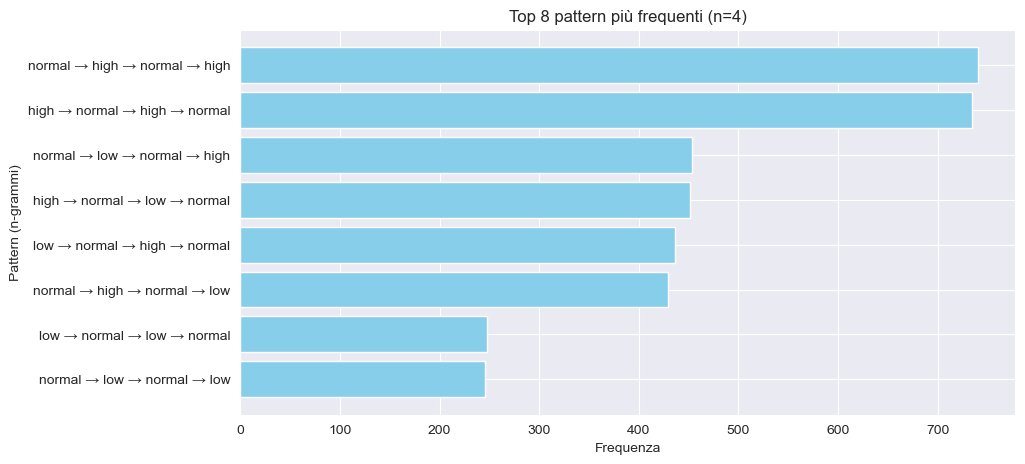

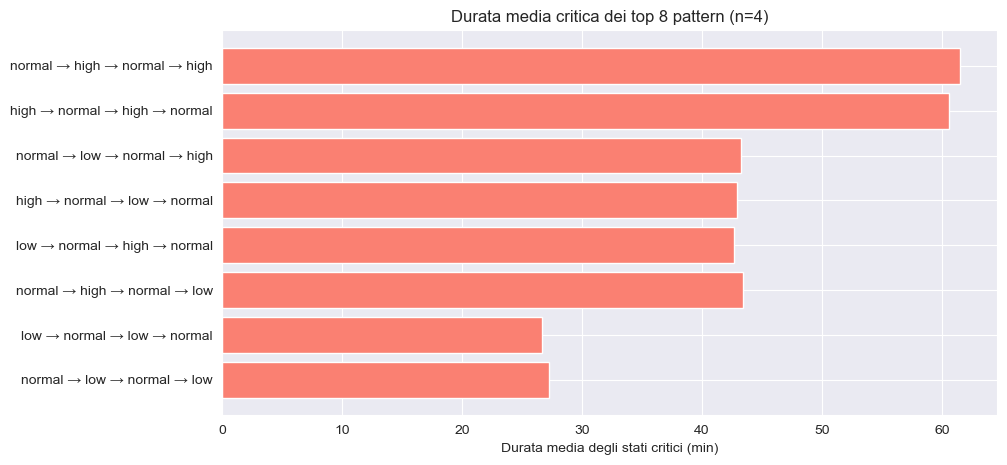

In [41]:


def calculate_gmi(gluc_data):
    """Calcola GMI e media glucosio da una lista di valori."""
    gluc_values = []
    for g in gluc_data:
        if isinstance(g, str) and g.lower() == "basso":
            gluc_values.append(50)
        else:
            gluc_values.append(float(g))
    avg = np.mean(gluc_values)
    gmi = 3.31 + 0.02392 * avg
    if gmi < 7:
        gmi_color = "🟢"
    elif gmi < 8:
        gmi_color = "🟡"
    else:
        gmi_color = "🔴"
    return gmi, avg, gmi_color



def simulate_random_sequence_realistic(
    G,
    total_minutes=10000,
    balanced=False,
    forced_length=None,
    noise_mode=False,
    borderline=False
):
    """
    Funzione MASTER per generare sequenze CGM realistiche.

    Parametri:
    - balanced=True  → target 1/3 verde, 1/3 giallo, 1/3 rosso
    - forced_length=N → lunghezza fissa in minuti
    - noise_mode=True → rumore tipo CGM
    - borderline=True → valori vicini alle soglie
    """

    from collections import defaultdict
    import numpy as np
    import random

    # Durata fissa opzionale
    if forced_length is not None:
        total_minutes = forced_length

    state_order = {
        "extremely_low": -2,
        "low": -1,
        "normal": 0,
        "high": 1,
        "extremely_high": 2
    }

    # Glucosio: range normale o borderline
    if borderline:
        glucose_ranges = {
            "extremely_low": (50, 60),
            "low": (75, 85),
            "normal": (110, 130),
            "high": (175, 185),
            "extremely_high": (240, 260)
        }
    else:
        glucose_ranges = {
            "extremely_low": (40, 55),
            "low": (56, 80),
            "normal": (81, 179),
            "high": (180, 249),
            "extremely_high": (250, 350)
        }

    # TARGET COLOR
    if balanced:
        target_color = random.choice([0.3, 0.4, 0.3])
    else:
        target_color = random.choices(
            ["verde", "giallo", "rosso"],
            weights=[0.6, 0.3, 0.1],
            k=1
        )[0]

    # Probabilità base per transizioni
    if target_color == "verde":
        base_probs = {"normal": 0.8, "high": 0.1, "low": 0.07, "extreme": 0.03}
    elif target_color == "giallo":
        base_probs = {"normal": 0.5, "high": 0.25, "low": 0.2, "extreme": 0.05}
    else:
        base_probs = {"normal": 0.2, "high": 0.4, "low": 0.3, "extreme": 0.1}

    duration_scale = 1.2
    noise_factor = 0.5

    state = "normal"
    seq = []
    tot_gluc = 0
    tot_time = 0
    elapsed = 0
    counts = defaultdict(int)

    # LOOP principale
    while elapsed < total_minutes:
        successors = list(G.successors(state))
        if not successors:
            state = random.choice(list(G.nodes))
            successors = list(G.successors(state))
            if not successors:
                continue

        pulse = 1 + np.sin(elapsed / 5000) * random.uniform(-0.2, 0.2)
        succ_probs = []

        for s in successors:
            if s == "normal":
                base = base_probs["normal"]
            elif abs(state_order[s]) == 1:
                base = base_probs["high"] if state_order[s] > 0 else base_probs["low"]
            else:
                base = base_probs["extreme"]

            base *= random.uniform(0.8, 1.2) * pulse
            base *= 1 / (1 + counts[s] / 60)
            succ_probs.append(base)

        succ_probs = np.array(succ_probs)
        succ_probs /= succ_probs.sum()
        next_state = random.choices(successors, succ_probs)[0]

        # Durata intervallo
        mean_dur = G[state][next_state].get("mean_duration", 30)
        factor = duration_scale * (1.3 - 0.25 * abs(state_order[next_state]))
        dur = np.random.normal(mean_dur * factor, mean_dur * noise_factor)
        dur = np.clip(dur, 1, 240)

        # Glucosio
        gmin, gmax = glucose_ranges[next_state]
        glucose_value = random.uniform(gmin, gmax)

        # Rumore CGM
        if noise_mode:
            glucose_value += np.random.normal(0, 8)
            glucose_value = max(40, min(glucose_value, 400))

        seq.append((next_state, round(dur, 1), round(glucose_value, 1)))
        tot_gluc += glucose_value * dur
        tot_time += dur
        counts[next_state] += 1
        state = next_state
        elapsed += dur

    # Calcolo GMI
    avg_gluc = tot_gluc / tot_time
    gmi = 3.31 + 0.02392 * avg_gluc

    if gmi < 7:
        gmi_color = "🟢 Verde"
    elif 7 <= gmi <= 8:
        gmi_color = "🟡 Giallo"
    else:
        gmi_color = "🔴 Rosso"

    # Colore effettivo tramite algoritmo
    true_color = analyze_simulate_sequence_compact(seq)[0]

    return seq, true_color, gmi, avg_gluc, gmi_color


def simulate_sequence_with_duration(G, start="normal", steps=100, step_minutes=5):
    """
    Simula sequenze Markov con durate realistiche e step_minutes per letture.
    - Evita transizioni duplicate consecutive (normal->normal non viene generato)
    - Le letture successive dello stesso stato sono aggregate
    - Le glicemie cambiano gradualmente con random walk realistico
    """
    state = start
    seq = []

    glucose_ranges = {
        "extremely_low": (40, 55),
        "low": (56, 80),
        "normal": (81, 179),
        "high": (180, 249),
        "extremely_high": (250, 350)
    }

    prev_glucose = np.random.uniform(*glucose_ranges[state])
    prev_state_in_seq = None

    for _ in range(steps):
        # Successori diversi dallo stato corrente
        successors = [s for s in G.successors(state) if s != state]
        if not successors:
            successors = [state]  # fallback: resta nello stesso stato

        probs = [G[state][s]["prob"] for s in successors]
        next_state = random.choices(successors, probs)[0]

        # Determina durata dello stato
        data = G[state][next_state]
        if "mean_duration" in data:
            mean_dur = data["mean_duration"]
            dur = max(step_minutes, np.random.normal(mean_dur, mean_dur * 0.3))
        elif "durations" in data and len(data["durations"]) > 0:
            dur = random.choice(data["durations"])
        else:
            dur = random.uniform(5, 15)

        # Numero di letture in step_minutes
        num_steps = max(1, int(dur / step_minutes))
        gmin, gmax = glucose_ranges[next_state]

        # Random walk e aggregazione letture consecutive
        for _ in range(num_steps):
            delta = np.random.uniform(-2, 2)  # variazione graduale
            gluc = max(gmin, min(gmax, prev_glucose + delta))

            if prev_state_in_seq == next_state and len(seq) > 0:
                last_state, last_dur, last_gluc = seq[-1]
                seq[-1] = (last_state, last_dur + step_minutes, gluc)
            else:
                seq.append((next_state, step_minutes, round(gluc, 0)))
                prev_state_in_seq = next_state

            prev_glucose = gluc

        state = next_state

    return seq


# --- Funzione per estrarre n-grammi con durate ---
def extract_ngrams(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        durations = [s[1] for s in seq[i:i + n]]
        ngrams[labels]['count'] += 1
        ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Analisi pattern frequenti e rari ---
def analyze_patterns_labels(seq, n=3, top_k=5):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} pattern più frequenti:")
    for labels, count in results_sorted[:top_k]:
        print(f"Pattern {labels} | count={count}")

    print(f"\nTop {top_k} pattern più rari:")
    for labels, count in results_sorted[-top_k:]:
        print(f"Pattern {labels} | count={count}")


# --- Grafico top pattern frequenti ---
def plot_top_patterns(seq, n=3, top_k=10):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)[:top_k]

    labels = [' → '.join(r[0]) for r in results_sorted]
    counts = [r[1] for r in results_sorted]

    plt.figure(figsize=(10, 5))
    plt.barh(labels, counts, color='skyblue')
    plt.xlabel("Frequenza")
    plt.ylabel("Pattern (n-grammi)")
    plt.title(f"Top {top_k} pattern più frequenti (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Grafico durata media dei pattern ---
def plot_mean_critical_duration_patterns(seq, n=3, top_k=10):
    critical_states = {"high", "low", "extremely_high", "extremely_low"}
    ngrams = extract_ngrams(seq, n=n)
    results = []

    for labels, data in ngrams.items():
        # calcola durata solo degli stati critici
        critical_durations = []
        for d in data['durations']:
            dur = sum(d[i] for i, s in enumerate(labels) if s in critical_states)
            critical_durations.append(dur)
        mean_critical = sum(critical_durations) / len(critical_durations)
        results.append((' → '.join(labels), mean_critical, data['count']))

    results_sorted = sorted(results, key=lambda x: x[2], reverse=True)[:top_k]

    plt.figure(figsize=(10, 5))
    plt.barh([r[0] for r in results_sorted], [r[1] for r in results_sorted], color='salmon')
    plt.xlabel("Durata media degli stati critici (min)")
    plt.title(f"Durata media critica dei top {top_k} pattern (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Visualizzazione grafo probabilistico ---
def plot_probabilistic_graph(G):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)
    edge_labels = {(u, v): f"{data['prob']:.2f}" for u, v, data in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Modello probabilistico delle transizioni glicemiche")
    plt.show()


# sim_seq = sequenza simulata con durate
sim_seq = simulate_sequence_with_duration(G, start="normal", steps=5000)

print("\nSequenza simulata:", sim_seq)

# 1 Analisi pattern frequenti e rari
analyze_patterns_labels(sim_seq, n=4, top_k=5)

# 2 Grafico pattern più frequenti
plot_top_patterns(sim_seq, n=4, top_k=8)

# 3 Grafico durata media dei pattern
plot_mean_critical_duration_patterns(sim_seq, n=4, top_k=8)

# 4 Visualizzazione grafo probabilistico
#plot_probabilistic_graph(G)


## Confronto empirico tra dati reali e simulati


In [13]:

def state_distribution_comparison(real_seq, sim_seq):
    # Conta le frequenze
    def calc_dist(seq):
        states = [s[0] for s in seq]
        counts = Counter(states)
        total = sum(counts.values())
        return {state: (count, count / total * 100) for state, count in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_states = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Stati ===")
    print(f"{'Stato':>10} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 62)
    for state in all_states:
        real_count, real_perc = real_dist.get(state, (0, 0))
        sim_count, sim_perc = sim_dist.get(state, (0, 0))
        print(f"{state:>10} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")
    print("-" * 62)
    print(f"{'Totale':>10} | {real_total:10d}{'':>11} | {sim_total:12d}")


def transition_distribution_comparison(real_seq, sim_seq):
    def calc_dist(seq):
        transitions = [(seq[i][0], seq[i + 1][0]) for i in range(len(seq) - 1)]
        counts = Counter(transitions)
        total = sum(counts.values())
        return {t: (c, c / total * 100) for t, c in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_transitions = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Transizioni ===")
    print(f"{'Transizione':>20} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 78)
    for t in all_transitions:
        real_count, real_perc = real_dist.get(t, (0, 0))
        sim_count, sim_perc = sim_dist.get(t, (0, 0))
        tr_label = f"{t[0]} → {t[1]}"
        print(f"{tr_label:>20} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")
    print("-" * 78)
    print(f"{'Totale':>20} | {real_total:10d}{'':>11} | {sim_total:12d}")


def average_duration_per_state(real_seq, sim_seq):
    # Calcolo media per stato, gestendo tuple di 2 o 3 elementi
    def calc_avg(seq):
        durations_per_state = defaultdict(list)
        for item in seq:
            if len(item) == 3:
                state, dur, _ = item
            elif len(item) == 2:
                state, dur = item
            else:
                raise ValueError(f"Unexpected tuple length {len(item)} in sequence: {item}")
            durations_per_state[state].append(dur)
        avg_per_state = {state: sum(durs) / len(durs) for state, durs in durations_per_state.items()}
        return avg_per_state

    real_avg = calc_avg(real_seq)
    sim_avg = calc_avg(sim_seq)

    all_states = sorted(set(real_avg.keys()) | set(sim_avg.keys()))

    print("\n=== Durata media per stato (minuti) ===")
    print(f"{'Stato':>15} | {'Reale':>10} | {'Simulato':>10}")
    print("-" * 40)
    for state in all_states:
        real_dur = real_avg.get(state, 0)
        sim_dur = sim_avg.get(state, 0)
        print(f"{state:>15} | {real_dur:10.2f} | {sim_dur:10.2f}")
    print("-" * 40)


# Esempio d'uso
state_distribution_comparison(seq, sim_seq)
transition_distribution_comparison(seq, sim_seq)
average_duration_per_state(seq, sim_seq)


=== Confronto Distribuzione Stati ===
     Stato |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
--------------------------------------------------------------
extremely_high |         12       5.71% |          290         5.80%
extremely_low |          3       1.43% |           82         1.64%
      high |         71      33.81% |         1713        34.26%
       low |         34      16.19% |          787        15.74%
    normal |         90      42.86% |         2128        42.56%
--------------------------------------------------------------
    Totale |        210            |         5000

=== Confronto Distribuzione Transizioni ===
         Transizione |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
------------------------------------------------------------------------------
extremely_high → high |         12       5.74% |          290         5.80%
 extremely_low → low |          3       1.44% |           82         1.64%
high → extremely_high |         12       5

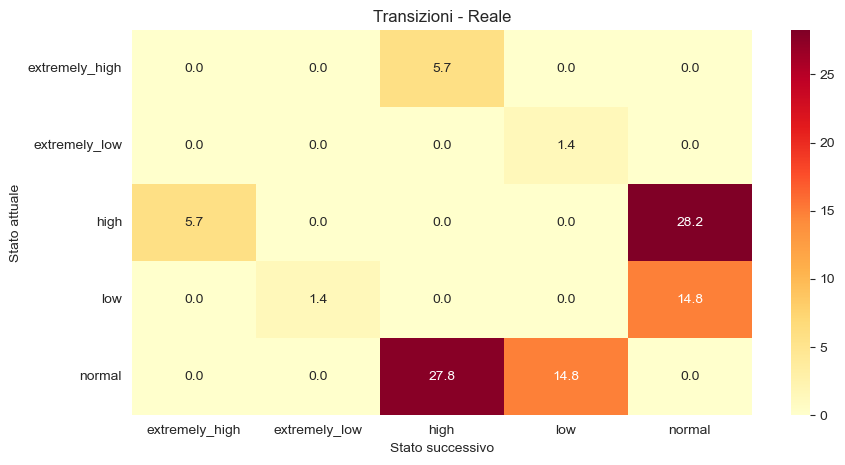

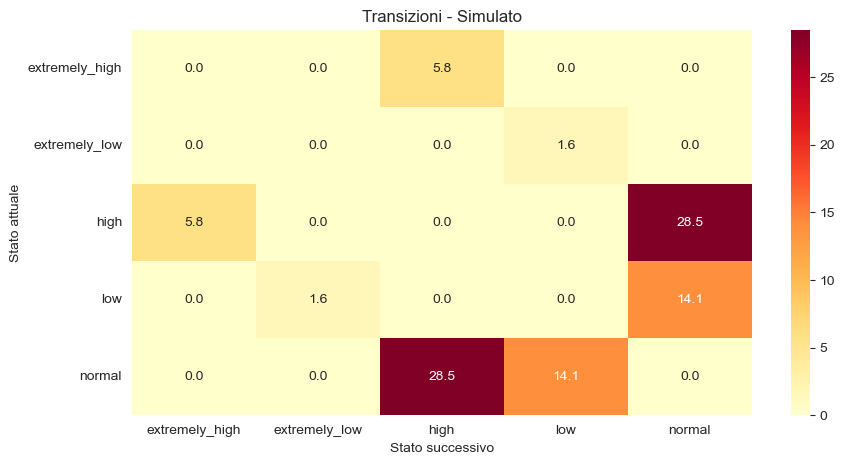

In [14]:

def plot_transition_heatmap(real_seq, sim_seq, normalize=True):
    """
    Visualizza una heatmap delle transizioni di stato per sequenze reali e simulate.

    Parametri:
    - real_seq, sim_seq: liste di tuple (state, duration) o (state, duration, glucose)
    - normalize: se True, mostra frequenze relative (%)
    """

    def get_transitions(seq):
        trans = Counter()
        for i in range(len(seq) - 1):
            s1 = seq[i][0]
            s2 = seq[i + 1][0]
            trans[(s1, s2)] += 1
        return trans

    # Transizioni
    real_trans = get_transitions(real_seq)
    sim_trans = get_transitions(sim_seq)

    # Tutti gli stati coinvolti
    all_states = sorted(set([s for s, _ in real_trans.keys()] + [s for _, s in real_trans.keys()] +
                            [s for s, _ in sim_trans.keys()] + [s for _, s in sim_trans.keys()]))

    # Matrice reale
    real_matrix = [[real_trans.get((i, j), 0) for j in all_states] for i in all_states]
    sim_matrix = [[sim_trans.get((i, j), 0) for j in all_states] for i in all_states]

    if normalize:
        # Frequenze relative
        total_real = sum(real_trans.values())
        total_sim = sum(sim_trans.values())
        real_matrix = [[v / total_real * 100 for v in row] for row in real_matrix]
        sim_matrix = [[v / total_sim * 100 for v in row] for row in sim_matrix]

    # Heatmap reale
    plt.figure(figsize=(10, 5))
    sns.heatmap(real_matrix, annot=True, fmt=".1f" if normalize else "d",
                xticklabels=all_states, yticklabels=all_states, cmap="YlOrRd")
    plt.title("Transizioni - Reale")
    plt.xlabel("Stato successivo")
    plt.ylabel("Stato attuale")
    plt.show()

    # Heatmap simulata
    plt.figure(figsize=(10, 5))
    sns.heatmap(sim_matrix, annot=True, fmt=".1f" if normalize else "d",
                xticklabels=all_states, yticklabels=all_states, cmap="YlOrRd")
    plt.title("Transizioni - Simulato")
    plt.xlabel("Stato successivo")
    plt.ylabel("Stato attuale")
    plt.show()


plot_transition_heatmap(seq, sim_seq, normalize=True)


## Algoritmo per assegnare soglie alle squenze

In [15]:
THRESHOLDS_DURATION = {
    "high": 90,
    "low": 30,
    "extremely_high": 45,
    "extremely_low": 10,
}


def analyze_simulate_sequence_compact(seq, analize_day=None):
    """
    Analisi compatta della sequenza.
    Restituisce solo lo stato finale (🟢🟡🔴) e il numero totale di anomalie.
    """
    if analize_day is None:
        total_minutes = sum(item[1] for item in seq)  # usa sempre il secondo elemento = durata
        analize_day = round(total_minutes / 1440)
    max_minutes = analize_day * 1440
    elapsed = 0

    states = ["extremely_high", "high", "normal", "low", "extremely_low"]
    counts = {s: 0 for s in states}
    durations = {s: 0 for s in states}

    transitions_of_interest = [
        ("normal", "high"), ("normal", "low"),
        ("low", "normal"), ("low", "extremely_low"),
        ("high", "normal"), ("high", "extremely_high"),
        ("extremely_low", "low"), ("extremely_high", "high")
    ]
    transition_counts = {t: 0 for t in transitions_of_interest}

    prev_state = None
    for item in seq:
        state = item[0]
        duration = item[1]

        if prev_state is not None and (prev_state, state) in transition_counts:
            transition_counts[(prev_state, state)] += 1
        prev_state = state
        elapsed += duration
        if elapsed >= max_minutes:
            break
        if state in counts:
            counts[state] += 1
            durations[state] += duration

    average_duration = {s: (durations[s] / counts[s] if counts[s] > 0 else 0) for s in states}

    thresholds_frequency = {
        "high": 3 * analize_day,
        "low": 3 * analize_day,
        "extremely_high": analize_day,
        "extremely_low": analize_day,
    }

    anomalies_frequency = sum(
        counts[s] >= thresholds_frequency.get(s, float('inf'))
        for s in thresholds_frequency
    )
    anomalies_duration = sum(
        average_duration[s] >= THRESHOLDS_DURATION.get(s, float('inf'))
        for s in THRESHOLDS_DURATION
    )
    total_anomalies = anomalies_frequency + anomalies_duration

    if total_anomalies <= 2:
        status = "🟢 Verde"
    elif total_anomalies <= 4:
        status = "🟡 Giallo"
    else:
        status = "🔴 Rosso"

    return status, total_anomalies


def plot_sequence(seq, index=None, status=None):
    """
    Crea un grafico per visualizzare l'evoluzione dello stato nel tempo.
    Compatibile con sequenze (state, duration) o (state, duration, glucose_value)
    """
    state_map = {
        "extremely_low": -2,
        "low": -1,
        "normal": 0,
        "high": 1,
        "extremely_high": 2
    }
    color_map = {
        -2: "#0044cc",  # blu
        -1: "#00aaff",  # azzurro
        0: "#00cc44",  # verde
        1: "#ffcc00",  # giallo
        2: "#ff3300"  # rosso
    }

    times = [0]
    values = [state_map[seq[0][0]] if seq else 0]

    for item in seq:
        state = item[0]
        duration = item[1]
        times.append(times[-1] + duration)
        values.append(state_map[state])

    plt.figure(figsize=(10, 3))
    for i in range(1, len(times)):
        plt.plot(times[i - 1:i + 1], values[i - 1:i + 1], color=color_map[values[i]], linewidth=2)
    plt.yticks([-2, -1, 0, 1, 2], ["ext_low", "low", "normal", "high", "ext_high"])
    plt.xlabel("Tempo (minuti)")
    plt.title(f"Sequenza {index} – Stato finale: {status}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def generate_and_test_models_compact(number_models=10, total_days=7, show_graph=True):
    total_minutes = total_days * 1440  # conversione giorni → minuti
    results = []

    for i in range(number_models):
        seq, target, gmi, avg_gluc, gmi_color = simulate_random_sequence_realistic(G, total_minutes)
        status, anomalies = analyze_simulate_sequence_compact(seq)
        results.append((status, anomalies, target))

        print(f"Modello {i}: {status}, anomalie: {anomalies}, target: {target}")

        if show_graph:
            plot_sequence(seq, index=i, status=status)

    status_counts = Counter([status for status, _, _ in results])
    anomalies_list = [anomalies for _, anomalies, _ in results]

    summary = {
        "status_counts": status_counts,
        "min_anomalies": min(anomalies_list),
        "max_anomalies": max(anomalies_list),
        "avg_anomalies": sum(anomalies_list) / len(anomalies_list)
    }

    print("\n" + "=" * 60)
    print(" RIEPILOGO DEI MODELLI ".center(60))
    print("=" * 60)
    for s, c in summary["status_counts"].items():
        perc = (c / len(results)) * 100
        print(f"{s}: {c} modelli ({perc:.1f}%)")
    print("-" * 60)
    print(f"Anomalie - min: {summary['min_anomalies']}, "
          f"max: {summary['max_anomalies']}, "
          f"media: {summary['avg_anomalies']:.2f}")
    print("=" * 60)

    return results, summary

## CODICE DI PROVA PER GENERARE ED ETICHETTARE MODELLI

Modello 0: 🟢 Verde, anomalie: 2, target: 🟢 Verde


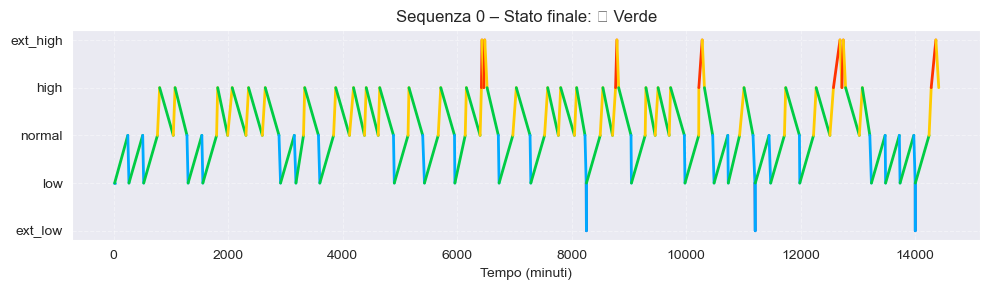

Modello 1: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


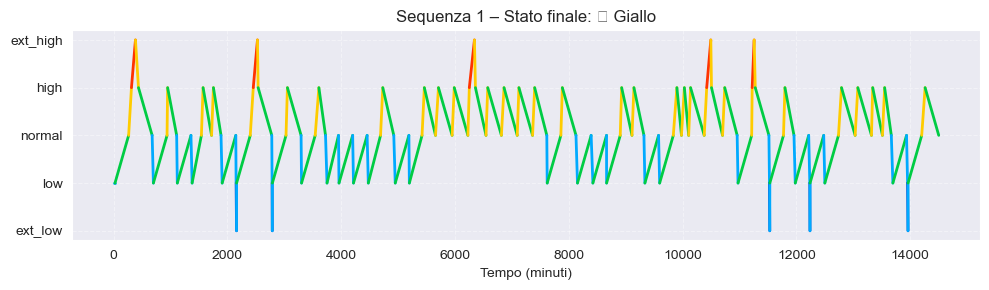

Modello 2: 🟢 Verde, anomalie: 2, target: 🟢 Verde


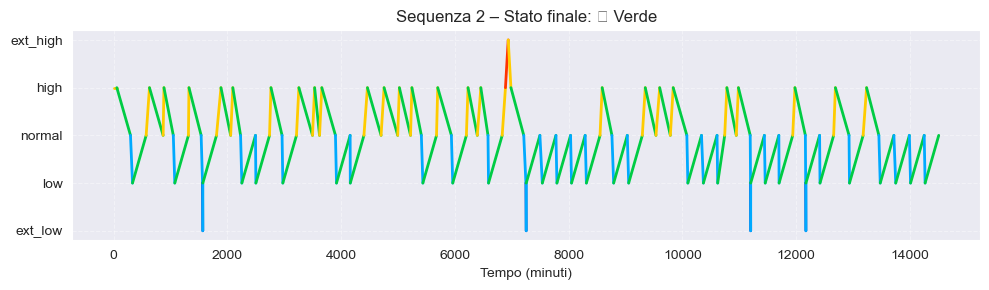

Modello 3: 🟢 Verde, anomalie: 2, target: 🟢 Verde


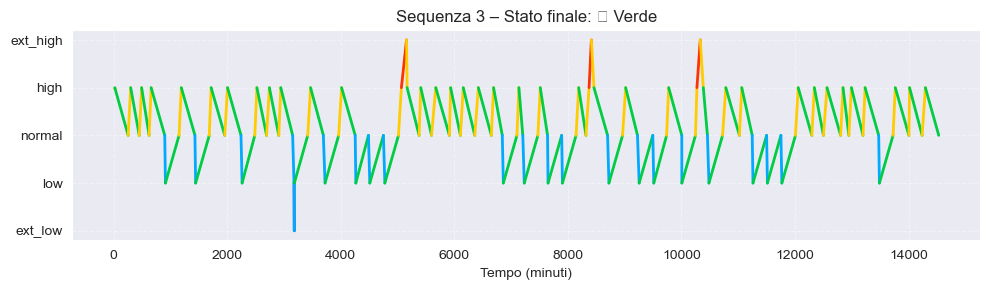

Modello 4: 🟢 Verde, anomalie: 2, target: 🟢 Verde


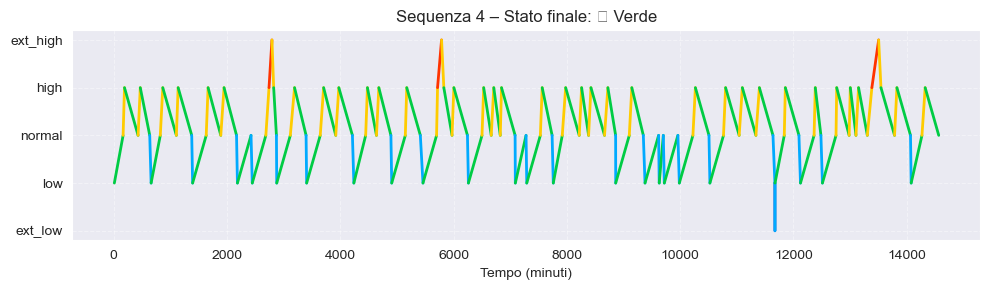

Modello 5: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


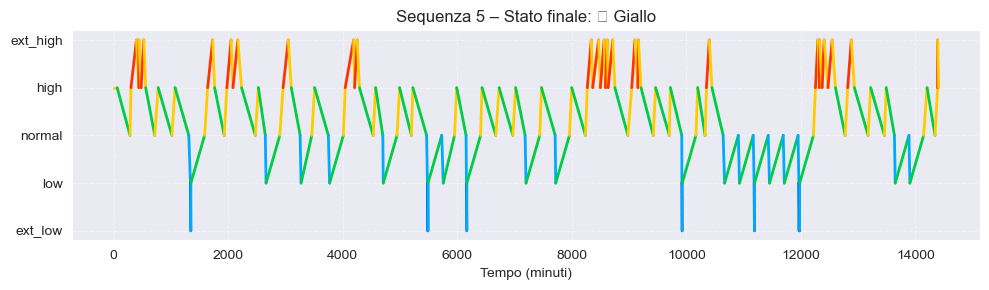

Modello 6: 🟢 Verde, anomalie: 1, target: 🟢 Verde


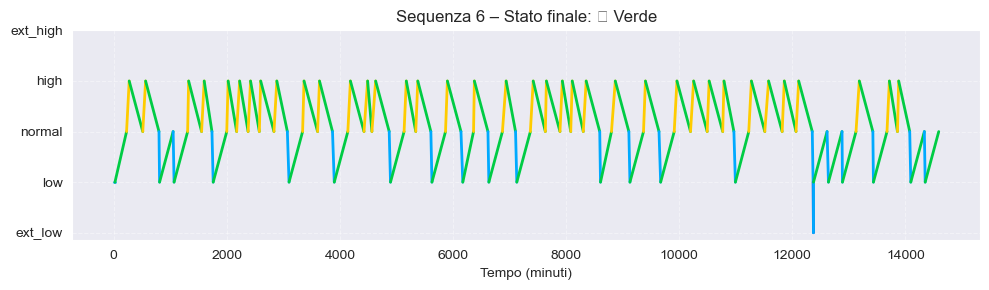

Modello 7: 🟢 Verde, anomalie: 2, target: 🟢 Verde


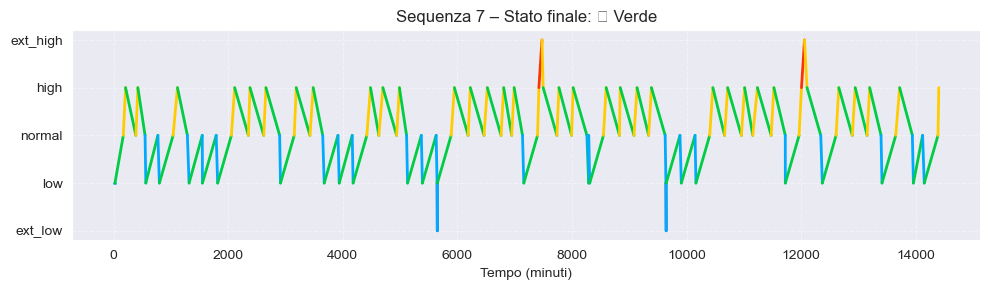

Modello 8: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


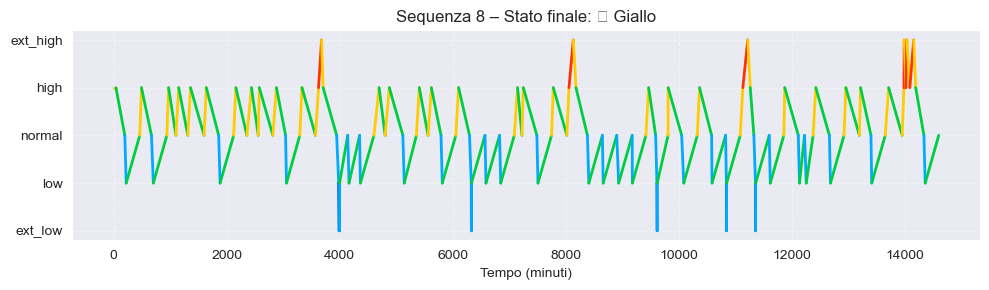

Modello 9: 🟢 Verde, anomalie: 2, target: 🟢 Verde


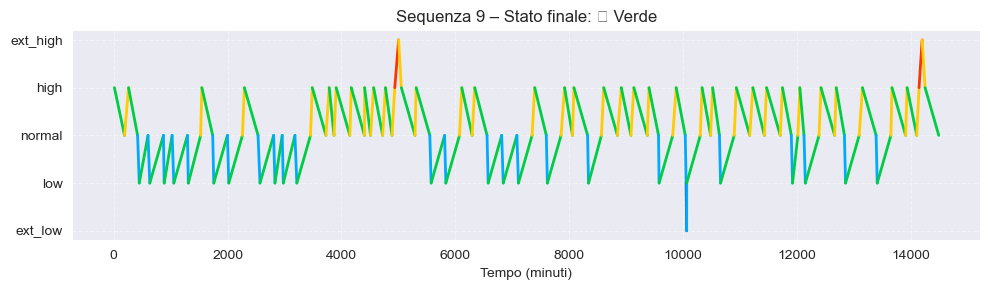

Modello 10: 🟢 Verde, anomalie: 2, target: 🟢 Verde


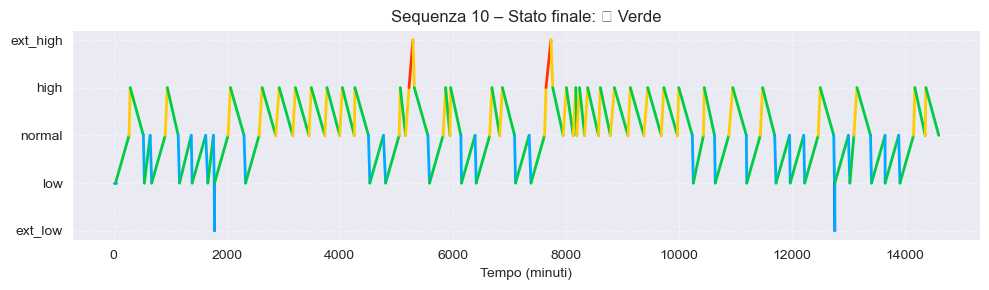

Modello 11: 🟢 Verde, anomalie: 2, target: 🟢 Verde


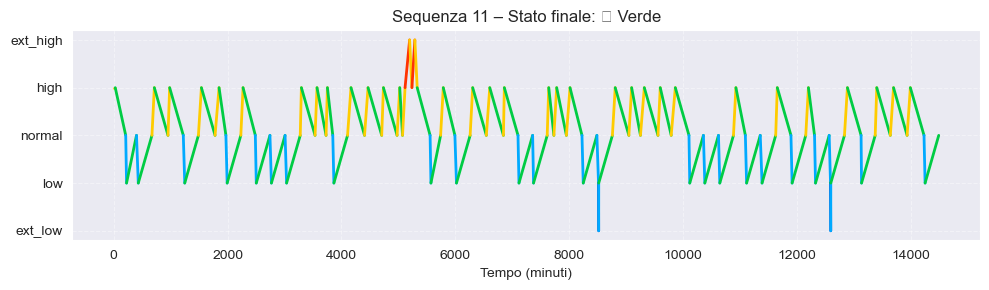

Modello 12: 🟢 Verde, anomalie: 2, target: 🟢 Verde


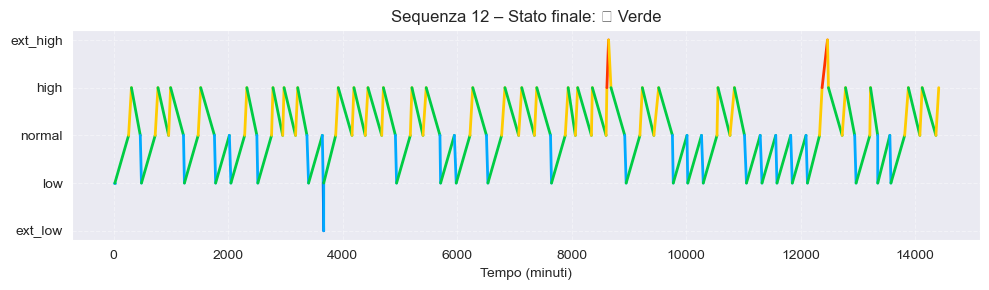

Modello 13: 🟢 Verde, anomalie: 2, target: 🟢 Verde


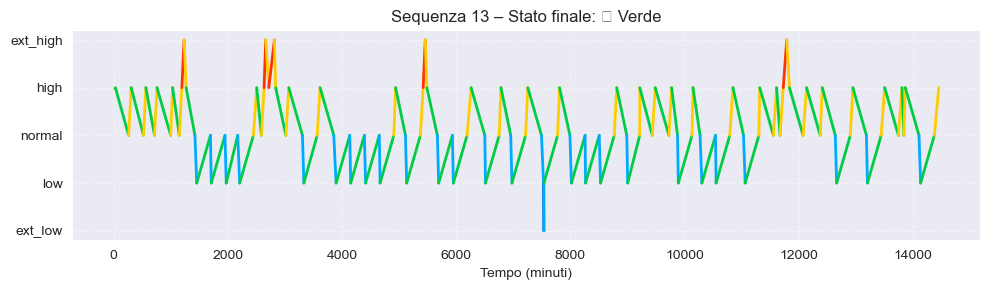

Modello 14: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


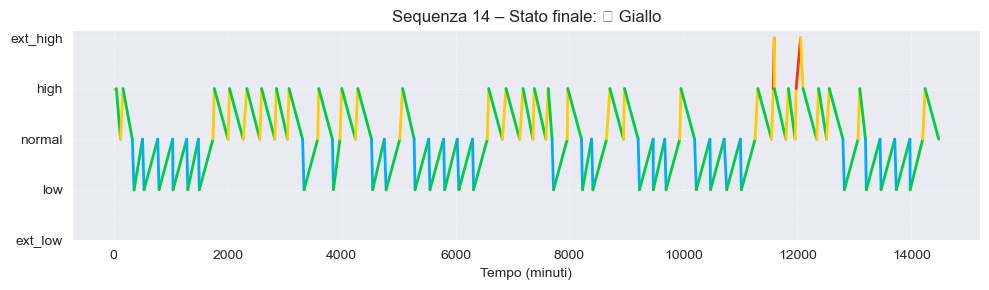

Modello 15: 🟢 Verde, anomalie: 1, target: 🟢 Verde


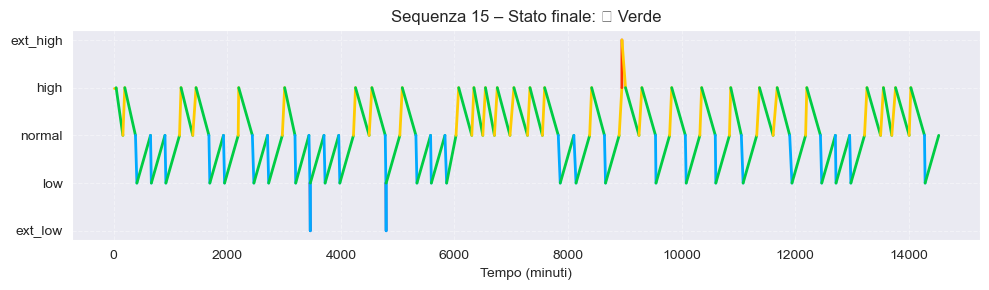

Modello 16: 🟢 Verde, anomalie: 2, target: 🟢 Verde


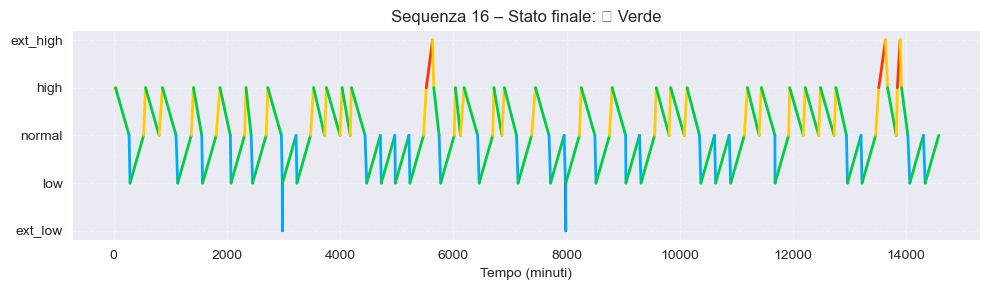

Modello 17: 🟢 Verde, anomalie: 2, target: 🟢 Verde


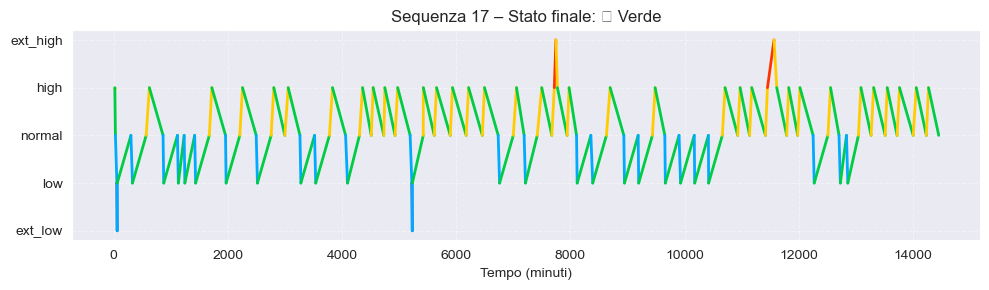

Modello 18: 🟢 Verde, anomalie: 2, target: 🟢 Verde


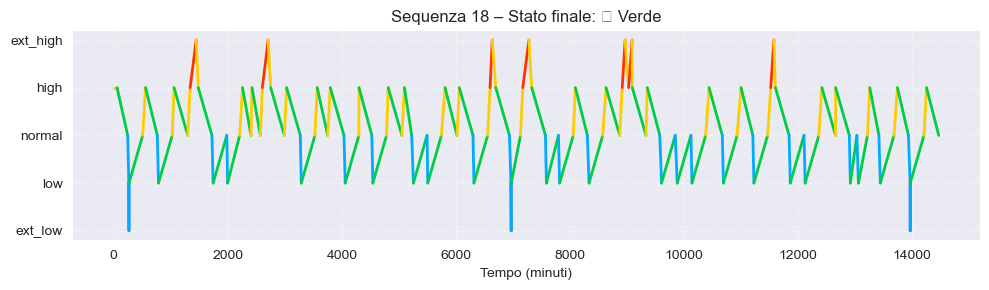

Modello 19: 🟢 Verde, anomalie: 2, target: 🟢 Verde


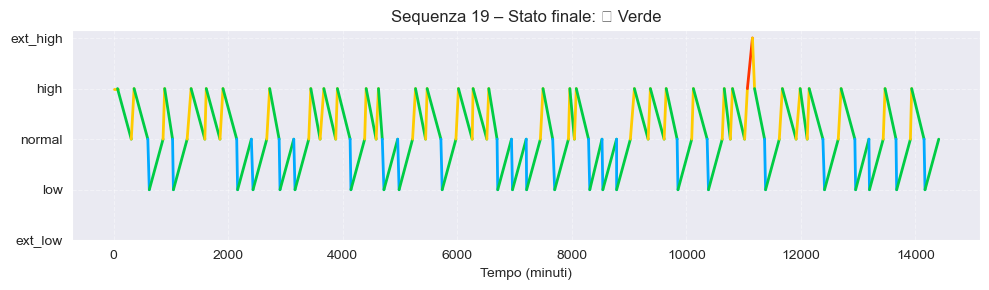


                   RIEPILOGO DEI MODELLI                    
🟢 Verde: 16 modelli (80.0%)
🟡 Giallo: 4 modelli (20.0%)
------------------------------------------------------------
Anomalie - min: 1, max: 3, media: 2.10
Modello 0: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 1: 🟡 Giallo, anomalie: 3, target simulato: 🟡 Giallo
Modello 2: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 3: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 4: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 5: 🟡 Giallo, anomalie: 3, target simulato: 🟡 Giallo
Modello 6: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 7: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 8: 🟡 Giallo, anomalie: 3, target simulato: 🟡 Giallo
Modello 9: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 10: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 11: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 12: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 13: 🟢 Verde

In [16]:

results, summary = generate_and_test_models_compact(number_models=20, total_days=10)

for i, (status, anomalies, target) in enumerate(results):
    print(f"Modello {i}: {status}, anomalie: {anomalies}, target simulato: {target}")

print("\n" + "=" * 60)
print(" RIEPILOGO DEI MODELLI".center(60))
print("=" * 60)

for s, c in summary["status_counts"].items():
    perc = (c / len(results)) * 100
    print(f"{s}: {c} modelli ({perc:.1f}%)")

print("-" * 60)
print(f"Anomalie - min: {summary['min_anomalies']}, "
      f"max: {summary['max_anomalies']}, "
      f"media: {summary['avg_anomalies']:.2f}")

if "mode_counts" in summary:
    print("\nModalità globali simulate:")
    for m, c in summary["mode_counts"].items():
        print(f"{m}: {c} modelli ({c / len(results) * 100:.1f}%)")

print("=" * 60)

## GENERAZIONE E ASSEGNAZIONE TARGET ALLE SEQUENZE SIMULATE

In [17]:

def extract_features(sequence, max_minutes=None):
    """
    Estrae feature numeriche da una sequenza per ML, incluse informazioni aggiuntive
    per catturare pattern sottili che l'algoritmo di targeting potrebbe non vedere.

    Parametri:
    - sequence: lista di tuple (state, duration[, glucose])
    - max_minutes: opzionale, limita la sequenza a tot minuti

    Restituisce:
    - dict di feature pronte per ML
    """

    states = ["extremely_low", "low", "normal", "high", "extremely_high"]
    counts = {s: 0 for s in states}
    durations = {s: 0 for s in states}
    transitions_of_interest = [
        ("normal", "high"), ("normal", "low"),
        ("low", "normal"), ("low", "extremely_low"),
        ("high", "normal"), ("high", "extremely_high"),
        ("extremely_low", "low"), ("extremely_high", "high")
    ]
    transition_counts = {t: 0 for t in transitions_of_interest}

    elapsed = 0
    prev_state = None
    glucose_values = []

    for item in sequence:
        # Compatibilità con tuple (state, dur) o (state, dur, glucose)
        if len(item) == 3:
            state, dur, glucose = item
            glucose_values.append(glucose)
        else:
            state, dur = item

        if max_minutes:
            elapsed += dur
            if elapsed > max_minutes:
                break

        counts[state] += 1
        durations[state] += dur

        if prev_state is not None and (prev_state, state) in transition_counts:
            transition_counts[(prev_state, state)] += 1
        prev_state = state

    total_time = sum(durations.values())
    features = {}

    for s in states:
        features[f"perc_time_{s}"] = durations[s] / total_time if total_time > 0 else 0
        features[f"avg_dur_{s}"] = durations[s] / counts[s] if counts[s] > 0 else 0
        features[f"count_{s}"] = counts[s]

    for t, c in transition_counts.items():
        features[f"trans_{t[0]}_{t[1]}"] = c / len(sequence) if len(sequence) > 0 else 0

    if glucose_values:
        deltas = np.diff(glucose_values)
        features["avg_glucose"] = np.mean(glucose_values)
        features["std_glucose"] = np.std(glucose_values)
        features["avg_delta_glucose"] = np.mean(deltas) if len(deltas) > 0 else 0
        features["std_delta_glucose"] = np.std(deltas) if len(deltas) > 0 else 0

        # GMI semplificato
        gmi = 3.31 + 0.02392 * features["avg_glucose"]
        features["gmi"] = gmi
        if gmi < 7:
            features["gmi_color"] = "🟢 Verde"
        elif gmi < 8:
            features["gmi_color"] = "🟡 Giallo"
        else:
            features["gmi_color"] = "🔴 Rosso"

    features["target"] = analyze_simulate_sequence_compact(sequence)[0]

    return features



import os
from datetime import datetime, timedelta
import pandas as pd

STATE_SYMBOL = {
    "extremely_high": "a",
    "high": "b",
    "normal": "c",
    "low": "d",
    "extremely_low": "e"
}


def save_intervals_csv(seq, filename, start_time="2024-02-13 00:01:32"):
    """
    Salva la sequenza in CSV con colonne:
    Start time, End time, Event, Duration
    Duration in formato '0 days hh:mm:ss' come da esempio.
    """
    import os
    from datetime import datetime, timedelta
    import pandas as pd

    if os.path.exists(filename):
        return  # già salvato

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    current_time = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    rows = []

    for item in seq:
        # Supporta sequenze (state, duration) o (state, duration, glucose)
        state, duration = item[:2]

        start_dt = current_time
        end_dt = start_dt + timedelta(minutes=duration)
        duration_td = end_dt - start_dt  # timedelta → '0 days hh:mm:ss'

        rows.append({
            "Start time": start_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "End time": end_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "Event": state,
            "Duration": duration_td
        })

        current_time = end_dt

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"[OK] CSV salvato → {filename}")


def save_intervals_epoch_simple(seq, filename, start_time="2024-02-13 00:01:32"):
    if os.path.exists(filename):
        return  # già salvato

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    start_dt = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    current_epoch = int(start_dt.timestamp())
    rows = []

    for state, duration, glucose in seq:
        start_e = current_epoch
        end_e = current_epoch + int(duration * 60)
        rows.append({
            "start_time": start_e,
            "end_time": end_e,
            "label": state
        })
        current_epoch = end_e

    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"[OK] Epoch-simple CSV → {filename}")


In [42]:
import os
import pandas as pd

def generate_simulated_sequences(G, num_sequences=30000, total_days=20, output_dir="simulated_intervals", ground_truth_balanced=False, forced_length = None, noise_mode = None, borderline = None):
    """
    Genera sequenze simulate realistiche, salva CSV per ciascun colore
    e restituisce un DataFrame con le feature estratte per ML.

    Parametri:
    - G: modello o oggetto per la simulazione delle sequenze
    - num_sequences: numero di sequenze da generare
    - total_days: lunghezza della sequenza in giorni
    - output_dir: cartella dove salvare i CSV

    Ritorna:
    - df: DataFrame contenente feature + target + sequenze originali
    """

    os.makedirs(output_dir, exist_ok=True)
    saved_colors = {"verde": False, "giallo": False, "rosso": False}
    total_minutes = total_days * 1440
    data = []

    for i in range(num_sequences):
        # Simula sequenza

        seq, true_color, gmi, avg_gluc, gmi_color = simulate_random_sequence_realistic(
            G,
            total_minutes=total_minutes,
            balanced=ground_truth_balanced,
            noise_mode=noise_mode,
            forced_length=forced_length,
            borderline=borderline,
        )
        # Estrai feature ML
        features = extract_features(seq, max_minutes=total_minutes)
        features["target"] = true_color
        features["sequence"] = seq
        data.append(features)

        # Standardizza colore
        color_key = None
        if "verde" in true_color.lower():
            color_key = "verde"
        elif "giallo" in true_color.lower():
            color_key = "giallo"
        elif "rosso" in true_color.lower():
            color_key = "rosso"

        # Salva CSV solo una volta per colore
        if color_key and not saved_colors[color_key]:
            labeling_file = f"{output_dir}/{color_key}_labeling.csv"
            epoch_file = f"{output_dir}/{color_key}_epoch.csv"
            save_intervals_csv(seq, labeling_file)
            save_intervals_epoch_simple(seq, epoch_file)
            saved_colors[color_key] = True

    # Crea DataFrame finale
    df = pd.DataFrame(data)

    # Stampa statistiche
    target_counts = df['target'].value_counts()
    total = target_counts.sum()
    print("Distribuzione dei target nel dataset:")
    for target, count in target_counts.items():
        perc = count / total * 100
        print(f"{target}: {count} sequenze ({perc:.1f}%)")

    return df



In [19]:
df = generate_simulated_sequences(G, num_sequences=30000, total_days=20)
analyze_simulate_sequence_compact(df['sequence'][100])

('🟢 Verde', 2)

In [20]:
df[1000:]

,perc_time_extremely_low,avg_dur_extremely_low,count_extremely_low,perc_time_low,avg_dur_low,count_low,perc_time_normal,avg_dur_normal,count_normal,perc_time_high,...,trans_extremely_low_low,trans_extremely_high_high,avg_glucose,std_glucose,avg_delta_glucose,std_delta_glucose,gmi,gmi_color,target,sequence
1000,0.001284,5.257143,7,0.041922,19.066667,63,0.830586,214.402703,111,0.098562,...,0.026718,0.045802,143.031298,69.034154,-0.435632,82.030092,6.731309,🟢 Verde,🟡 Giallo,"[(high, 48.3, 232.2), (extremely_high, 75.5, 3..."
1001,0.000143,1.366667,3,0.037309,19.412727,55,0.843539,204.575424,118,0.103793,...,0.011538,0.030769,143.248846,62.118415,0.064093,78.044592,6.736512,🟢 Verde,🟢 Verde,"[(low, 9.2, 64.8), (normal, 240, 178.5), (high..."
1002,0.005329,5.113333,30,0.027890,11.636232,69,0.755593,207.164762,105,0.138980,...,0.088757,0.097633,152.492308,81.193807,-0.424036,81.246779,6.957616,🟢 Verde,🔴 Rosso,"[(high, 35.2, 243.6), (normal, 138.8, 161.9), ..."
1003,0.007846,5.127273,44,0.033063,10.682022,89,0.748278,215.162000,100,0.121022,...,0.119891,0.103542,143.534605,81.826523,0.413115,73.397708,6.743348,🟢 Verde,🔴 Rosso,"[(low, 17.4, 59.9), (normal, 240, 133.4), (low..."
1004,0.000831,5.950000,4,0.036728,19.120000,55,0.845588,206.929915,117,0.110600,...,0.016000,0.012000,143.108400,61.733497,-0.270281,82.995887,6.733153,🟢 Verde,🟢 Verde,"[(high, 41.3, 244.1), (normal, 103.1, 82.3), (..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.000494,7.100000,2,0.043338,21.456897,58,0.838422,213.064602,113,0.092558,...,0.008000,0.036000,141.991200,63.816513,-0.481928,81.650523,6.706430,🟢 Verde,🟢 Verde,"[(high, 58.5, 206.9), (normal, 213.2, 157.5), ..."
29996,0.000874,4.183333,6,0.036608,17.526667,60,0.858572,214.466087,115,0.094293,...,0.023622,0.019685,139.095669,62.056342,-0.569565,78.203976,6.637168,🟢 Verde,🟡 Giallo,"[(high, 52.1, 242.5), (extremely_high, 27.6, 3..."
29997,0.000425,6.100000,2,0.034865,20.018000,50,0.849676,215.862832,113,0.103915,...,0.008333,0.016667,144.073750,61.065970,-0.517992,81.493541,6.756244,🟢 Verde,🟢 Verde,"[(high, 33.8, 206.1), (normal, 240, 110.0), (l..."
29998,0.000358,10.300000,1,0.032930,19.756250,48,0.855690,216.157018,114,0.108530,...,0.004274,0.004274,144.400427,58.062328,-0.384120,82.027305,6.764058,🟢 Verde,🟡 Giallo,"[(high, 73.9, 202.8), (normal, 199.6, 124.2), ..."


In [21]:
df[["gmi", "gmi_color", "target"]]

,gmi,gmi_color,target
0,6.778467,🟢 Verde,🟢 Verde
1,6.797644,🟢 Verde,🔴 Rosso
2,6.894080,🟢 Verde,🟢 Verde
3,6.626596,🟢 Verde,🟡 Giallo
4,6.725221,🟢 Verde,🟡 Giallo
...,...,...,...
29995,6.706430,🟢 Verde,🟢 Verde
29996,6.637168,🟢 Verde,🟡 Giallo
29997,6.756244,🟢 Verde,🟢 Verde
29998,6.764058,🟢 Verde,🟡 Giallo


## Apprendimento per riconoscere target sulle sequenze


Distribuzione delle classi in Train/Test:


,Classe,Train (%),Test (%),Totale (%)
0,🔴 Rosso,10.03,10.03,10.03
1,🟡 Giallo,25.18,25.18,25.18
2,🟢 Verde,64.79,64.78,64.79



=== Random Forest ===
n_estimators=10, Loss=0.0100
n_estimators=20, Loss=0.0120
n_estimators=30, Loss=0.0144
n_estimators=40, Loss=0.0145
n_estimators=50, Loss=0.0156
n_estimators=60, Loss=0.0161

Accuracy sul test set: 0.9997
Loss sul test set: 0.0161

Classification Report:

              precision    recall  f1-score   support

     🔴 Rosso       1.00      1.00      1.00       602
    🟡 Giallo       1.00      1.00      1.00      1511
     🟢 Verde       1.00      1.00      1.00      3887

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



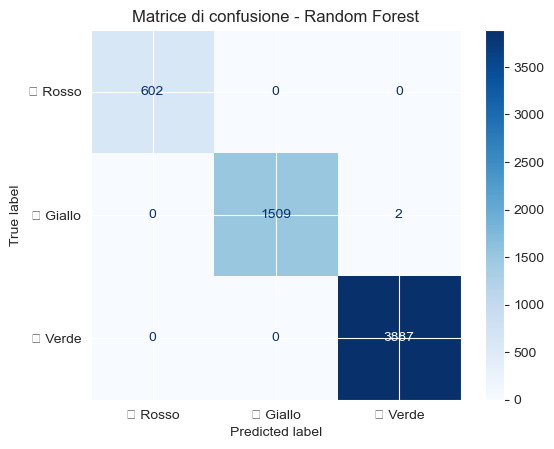


=== MLP ===
Numero di epoche completate prima dell'early stopping: 55

Accuracy sul test set: 0.9913
Loss sul test set: 0.0496

Classification Report:

              precision    recall  f1-score   support

     🔴 Rosso       1.00      1.00      1.00       602
    🟡 Giallo       0.99      0.98      0.98      1511
     🟢 Verde       0.99      1.00      0.99      3887

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



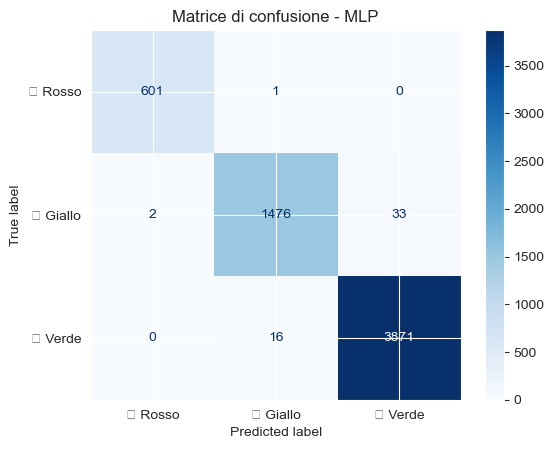

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Preparazione dati ---
color_map = {"🟢 Verde": 0, "🟡 Giallo": 1, "🔴 Rosso": 2}
df["gmi_color_num"] = df["gmi_color"].map(color_map)
X = df.drop(columns=["target", "sequence", "gmi_color", "gmi", "gmi_color_num", "avg_glucose", "std_glucose"])
y = df["target"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Distribuzione classi
train_dist = np.bincount(y_train) / len(y_train)
test_dist = np.bincount(y_test) / len(y_test)
check_df = pd.DataFrame({
    "Classe": le.classes_,
    "Train (%)": np.round(train_dist * 100, 2),
    "Test (%)": np.round(test_dist * 100, 2),
    "Totale (%)": np.round((np.bincount(y_train) + np.bincount(y_test)) / (len(y_train) + len(y_test)) * 100, 2)
})
print("\nDistribuzione delle classi in Train/Test:")
display(check_df)

# --- Definizione modelli ---
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=10,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        warm_start=True
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        early_stopping=True,
    )
}


for name, clf in models.items():
    print(f"\n=== {name} ===")

    if name == "Random Forest":
        best_loss = np.inf
        no_improve_rounds = 0
        max_no_improve = 5
        n_estimators_step = 10
        max_estimators = 200

        while clf.n_estimators <= max_estimators and no_improve_rounds < max_no_improve:
            clf.fit(X_train, y_train)
            y_proba = clf.predict_proba(X_test)
            loss = log_loss(y_test, y_proba)
            print(f"n_estimators={clf.n_estimators}, Loss={loss:.4f}")

            if loss < best_loss - 1e-4:
                best_loss = loss
                no_improve_rounds = 0
            else:
                no_improve_rounds += 1

            clf.n_estimators += n_estimators_step

    elif name == "MLP":
        clf.fit(X_train, y_train)
        print(f"Numero di epoche completate prima dell'early stopping: {clf.n_iter_}")

    else:  # XGBoost normale
        clf.fit(X_train, y_train)

    # Valutazione finale
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_proba)

    print(f"\nAccuracy sul test set: {acc:.4f}")
    print(f"Loss sul test set: {loss:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matrice di confusione - {name}")
    plt.show()

# GROUND TRUTH

In [23]:
event_map = {
    "extremely_low": 0,
    "low": 1,
    "normal": 2,
    "high": 3,
    "extremely_high": 4
}

color_map = {"🟢 Verde": 0, "🟡 Giallo": 1, "🔴 Rosso": 2}
inv_color_map = {v: k for k, v in color_map.items()}


def csv_to_sequence(csv_path):
    df = pd.read_csv(csv_path)
    df["duration_minutes"] = pd.to_timedelta(df["Duration"]).dt.total_seconds() / 60
    df["state_num"] = df["Event"].map(event_map)
    sequence = df[["state_num", "duration_minutes"]].values.tolist()
    return sequence


def prepare_lstm_dataset(sequences, targets, max_seq_len=None):
    X_numeric = []
    for seq in sequences:
        numeric_seq = []
        for item in seq:
            if len(item) == 2:
                state, dur = item
            elif len(item) == 3:
                state, dur, _ = item
            else:
                raise ValueError(f"Elemento sequenza inatteso: {item}")
            state_num = event_map[state] if isinstance(state, str) else state
            numeric_seq.append([state_num, dur])
        X_numeric.append(numeric_seq)

    if max_seq_len is None:
        max_seq_len = max(len(s) for s in X_numeric)

    X_padded = pad_sequences(X_numeric, maxlen=max_seq_len, padding='post', value=0.0, dtype='float32')
    y_encoded = to_categorical([color_map[c] for c in targets], num_classes=3)
    return X_padded, y_encoded, max_seq_len


def build_lstm_model(input_shape, hidden_units=64, num_classes=3):
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=input_shape))
    model.add(LSTM(hidden_units, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def predict_lstm(model, sequence, max_seq_len):
    """
    sequence: lista di tuple (state, duration) o (state, duration, glucose)
    """
    X_seq = []
    for item in sequence:
        if len(item) == 2:
            state, dur = item
        elif len(item) == 3:
            state, dur, _ = item  # ignora il glucosio
        else:
            raise ValueError(f"Elemento sequenza inatteso: {item}")

        state_num = event_map[state] if isinstance(state, str) else state
        X_seq.append([state_num, dur])

    X_padded = pad_sequences([X_seq], maxlen=max_seq_len, padding='post', value=0.0, dtype='float32')
    y_proba = model.predict(X_padded, verbose=0)[0]
    pred_idx = np.argmax(y_proba)
    pred_label = inv_color_map[pred_idx]
    confidence = float(y_proba[pred_idx])

    return {
        "predicted_label": pred_label,
        "probabilities": {inv_color_map[i]: float(p) for i, p in enumerate(y_proba)},
        "confidence_score": confidence
    }

In [28]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import os
import numpy as np
import pandas as pd

model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "lstm_glucose_model.h5")
log_path = os.path.join(model_dir, "lstm_training_log.csv")


if os.path.exists(model_path):
    print(f"[OK] Modello trovato: {model_path}, lo carico...")
    model = load_model(model_path)

else:
    print("[INFO] Modello non trovato, addestramento in corso...")

    # Genera dataset
    df = generate_simulated_sequences(G, num_sequences=30000, total_days=30)

    # Prepara dati
    sequences = df["sequence"].tolist()
    targets = df["target"].tolist()

    X_padded, y_encoded, max_seq_len = prepare_lstm_dataset(sequences, targets)

    # Split stratificato per miglior validazione
    y_labels = np.argmax(y_encoded, axis=1)
    X_train, X_val, y_train, y_val = train_test_split(
        X_padded, y_encoded, test_size=0.2, stratify=y_labels, random_state=42
    )

    # Calcolo pesi per classi sbilanciate
    class_weights_raw = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_labels),
        y=y_labels
    )
    class_weights = {i: float(w) for i, w in enumerate(class_weights_raw)}
    print("Class weights:", class_weights)

    # Costruisci modello
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(max_seq_len, 2)))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Callbacks ottimizzati
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=model_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(log_path, append=True)
    ]

    # Training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    print(f"[OK] Modello salvato in {model_path}")

[INFO] Modello non trovato, addestramento in corso...
Distribuzione dei target nel dataset:
🟢 Verde: 18282 sequenze (60.9%)
🟡 Giallo: 8706 sequenze (29.0%)
🔴 Rosso: 3012 sequenze (10.0%)
Class weights: {0: 0.5469861065528936, 1: 1.1486331265793706, 2: 3.3200531208499338}
Epoch 1/50
375/375 [==============================] - ETA: 0s - loss: 0.4734 - accuracy: 0.8080
Epoch 1: val_loss improved from inf to 0.37017, saving model to saved_models/lstm_glucose_model.h5
375/375 [==============================] - 78s 206ms/step - loss: 0.4734 - accuracy: 0.8080 - val_loss: 0.3702 - val_accuracy: 0.8597 - lr: 0.0010
Epoch 2/50
375/375 [==============================] - ETA: 0s - loss: 0.2846 - accuracy: 0.8470
Epoch 2: val_loss did not improve from 0.37017
375/375 [==============================] - 80s 212ms/step - loss: 0.2846 - accuracy: 0.8470 - val_loss: 0.5107 - val_accuracy: 0.8310 - lr: 0.0010
Epoch 3/50
375/375 [==============================] - ETA: 0s - loss: 0.2721 - accuracy: 0.8533


In [38]:


def evaluate_sequences(model, sequences_df, max_seq_len):
    matches = 0
    diffs = []

    for idx, row in sequences_df.iterrows():
        seq = row["sequence"]
        true_color = row["target"]

        pred = predict_lstm(model, seq, max_seq_len)
        pred_label = pred["predicted_label"]

        if pred_label == true_color:
            matches += 1
        else:
            diffs.append({
                "sequence_idx": idx,
                "predicted": pred_label,
                "true_color": true_color,
                "confidence": pred['confidence_score']
            })

    total = len(sequences_df)
    acc = matches / total * 100

    print(f"\n--- TEST RESULT ---")
    print(f"Totale sequenze: {total}")
    print(f"Concordanza: {matches} ({acc:.2f}%)")
    print(f"Divergenze: {len(diffs)} ({100-acc:.2f}%)")

    if diffs:
        return pd.DataFrame(diffs).sort_values("confidence")
    return pd.DataFrame()

In [39]:
print("\n==========================")
print("TEST 1 — Dataset Bilanciato (1/3, 1/3, 1/3)")
print("==========================")

df_test1 = generate_simulated_sequences(
    G, num_sequences=600, total_days=10, ground_truth_balanced=True
)

diffs_test1 = evaluate_sequences(model, df_test1, max_seq_len)
display(diffs_test1)

print("\n==========================")
print("TEST 2 — Sequenze Corte/Medie/Lunghe")
print("==========================")

length_configs = [
    ("Corte (1–3 ore)", 180),
    ("Medie (6–12 ore)", 720),
    ("Lunghe (24–48 ore)", 2880),
]

for label, minutes in length_configs:
    print(f"\n--- {label} ---")
    df_test_len = generate_simulated_sequences(
        G, num_sequences=400, total_days=1, forced_length=minutes
    )
    diffs = evaluate_sequences(model, df_test_len, max_seq_len)
    display(diffs.head(10))

print("\n==========================")
print("TEST 3 — Dataset Rumoroso (CGM-like)")
print("==========================")

df_test3 = generate_simulated_sequences(
    G, num_sequences=500, total_days=10, noise_mode=True
)

diffs_test3 = evaluate_sequences(model, df_test3, max_seq_len)
display(diffs_test3)

print("\n==========================")
print("==========================")

df_test4 = generate_simulated_sequences(
    G, num_sequences=500, total_days=5, borderline=True
)

diffs_test4 = evaluate_sequences(model, df_test4, max_seq_len)
display(diffs_test4)




TEST 1 — Dataset Bilanciato (1/3, 1/3, 1/3)
Distribuzione dei target nel dataset:
🟢 Verde: 323 sequenze (53.8%)
🔴 Rosso: 140 sequenze (23.3%)
🟡 Giallo: 137 sequenze (22.8%)

--- TEST RESULT ---
Totale sequenze: 600
Concordanza: 480 (80.00%)
Divergenze: 120 (20.00%)


,sequence_idx,predicted,true_color,confidence
80,388,🟢 Verde,🟡 Giallo,0.518334
46,227,🟢 Verde,🔴 Rosso,0.519432
24,100,🟡 Giallo,🔴 Rosso,0.532201
110,549,🟢 Verde,🟡 Giallo,0.535266
4,16,🟢 Verde,🟡 Giallo,0.538491
...,...,...,...,...
33,147,🟡 Giallo,🔴 Rosso,0.997665
60,296,🟢 Verde,🟡 Giallo,0.998979
63,305,🟢 Verde,🟡 Giallo,0.999499
82,398,🟢 Verde,🟡 Giallo,0.999578



TEST 2 — Sequenze Corte/Medie/Lunghe

--- Corte (1–3 ore) ---
Distribuzione dei target nel dataset:
🟡 Giallo: 400 sequenze (100.0%)

--- TEST RESULT ---
Totale sequenze: 400
Concordanza: 4 (1.00%)
Divergenze: 396 (99.00%)


,sequence_idx,predicted,true_color,confidence
345,348,🔴 Rosso,🟡 Giallo,0.377011
96,98,🔴 Rosso,🟡 Giallo,0.430862
35,36,🟢 Verde,🟡 Giallo,0.436165
385,389,🔴 Rosso,🟡 Giallo,0.502598
22,23,🔴 Rosso,🟡 Giallo,0.553023
107,110,🔴 Rosso,🟡 Giallo,0.568930
118,121,🔴 Rosso,🟡 Giallo,0.675738
25,26,🔴 Rosso,🟡 Giallo,0.679474
262,265,🔴 Rosso,🟡 Giallo,0.818567
217,220,🟢 Verde,🟡 Giallo,0.906881



--- Medie (6–12 ore) ---
Distribuzione dei target nel dataset:
🟢 Verde: 356 sequenze (89.0%)
🟡 Giallo: 44 sequenze (11.0%)

--- TEST RESULT ---
Totale sequenze: 400
Concordanza: 339 (84.75%)
Divergenze: 61 (15.25%)


,sequence_idx,predicted,true_color,confidence
15,84,🟡 Giallo,🟢 Verde,0.491797
13,80,🟡 Giallo,🟢 Verde,0.549866
29,199,🟡 Giallo,🟢 Verde,0.587404
16,86,🟡 Giallo,🟢 Verde,0.600168
27,186,🟡 Giallo,🟢 Verde,0.615101
9,62,🔴 Rosso,🟡 Giallo,0.631085
46,312,🟡 Giallo,🟢 Verde,0.644061
51,334,🟡 Giallo,🟢 Verde,0.664668
1,8,🟡 Giallo,🟢 Verde,0.684112
18,96,🟡 Giallo,🟢 Verde,0.727213



--- Lunghe (24–48 ore) ---
Distribuzione dei target nel dataset:
🟢 Verde: 319 sequenze (79.8%)
🟡 Giallo: 70 sequenze (17.5%)
🔴 Rosso: 11 sequenze (2.8%)

--- TEST RESULT ---
Totale sequenze: 400
Concordanza: 319 (79.75%)
Divergenze: 81 (20.25%)


,sequence_idx,predicted,true_color,confidence
52,269,🟡 Giallo,🔴 Rosso,0.543051
78,373,🟡 Giallo,🟢 Verde,0.543338
71,342,🔴 Rosso,🟡 Giallo,0.544767
6,49,🟡 Giallo,🟢 Verde,0.547756
77,371,🟢 Verde,🟡 Giallo,0.576710
8,55,🟢 Verde,🔴 Rosso,0.592788
76,370,🟢 Verde,🟡 Giallo,0.611962
31,177,🟢 Verde,🟡 Giallo,0.613444
20,142,🟡 Giallo,🟢 Verde,0.614296
1,6,🟡 Giallo,🟢 Verde,0.626057



TEST 3 — Dataset Rumoroso (CGM-like)
Distribuzione dei target nel dataset:
🟢 Verde: 360 sequenze (72.0%)
🟡 Giallo: 93 sequenze (18.6%)
🔴 Rosso: 47 sequenze (9.4%)

--- TEST RESULT ---
Totale sequenze: 500
Concordanza: 406 (81.20%)
Divergenze: 94 (18.80%)


,sequence_idx,predicted,true_color,confidence
23,94,🟢 Verde,🟡 Giallo,0.507853
21,89,🟢 Verde,🟡 Giallo,0.519712
11,44,🟢 Verde,🟡 Giallo,0.527248
31,132,🟢 Verde,🟡 Giallo,0.528695
76,412,🟡 Giallo,🟢 Verde,0.543415
...,...,...,...,...
1,1,🟢 Verde,🟡 Giallo,0.998059
45,220,🟡 Giallo,🔴 Rosso,0.998466
50,257,🟢 Verde,🟡 Giallo,0.999050
69,352,🟢 Verde,🟡 Giallo,0.999580


In [ ]:
from collections import Counter
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


NGRAM_N = 3
TOP_K_NGRAMS = 3000
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
RANDOM_STATE = 42


# -----------------------------
# Funzioni ausiliarie
# -----------------------------
def discretize_duration_by_state(state, dur, thresholds):
    """
    Discretizza la durata di uno stato in breve (N) o lunga (L) rispetto alla soglia specifica.
    """
    thr = thresholds.get(state, 30)
    return "N" if dur < thr else "L"


def build_ngram_vocab(sequences, n=NGRAM_N, top_k=TOP_K_NGRAMS):
    """
    Costruisce il vocabolario dei n-gram più frequenti da una lista di sequenze.
    """
    counter = Counter()
    for seq in tqdm(sequences, desc="Conteggio n-gram"):
        if len(seq) < n:
            continue
        states = [s for s, _, _ in seq]
        durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, _ in seq]
        # Genera n-gram e aggiorna contatore
        for i in range(len(seq) - n + 1):
            ng = "_".join(f"{st}({du})" for st, du in zip(states[i:i + n], durs[i:i + n]))
            counter[ng] += 1
    # Restituisce solo i top_k n-gram più frequenti
    return [ng for ng, _ in counter.most_common(top_k)]


def sequences_to_sparse_matrix(sequences, vocab, n=NGRAM_N):
    """
    Trasforma le sequenze in una matrice sparsa n-gram (conteggio frequenze).
    """
    vocab_index = {ng: i for i, ng in enumerate(vocab)}
    row_idx, col_idx, data = [], [], []

    for seq_id, seq in enumerate(tqdm(sequences, desc="Vettorizzazione")):
        if len(seq) < n:
            continue
        states = [s for s, _, _ in seq]
        durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, _ in seq]
        counts = Counter()
        for i in range(len(seq) - n + 1):
            ng = "_".join(f"{st}({du})" for st, du in zip(states[i:i + n], durs[i:i + n]))
            if ng in vocab_index:
                counts[vocab_index[ng]] += 1
        for col, c in counts.items():
            row_idx.append(seq_id)
            col_idx.append(col)
            data.append(c)

    return csr_matrix((data, (row_idx, col_idx)), shape=(len(sequences), len(vocab)))


def analyze_distribution_by_target(df, n=NGRAM_N, top_k=TOP_K_NGRAMS):
    """
    Analizza la distribuzione delle sequenze per target usando UMAP e PCA.
    """
    if df.empty:
        print("Dataset vuoto.")
        return

    sequences = df["sequence"].tolist()
    print(f"Numero sequenze: {len(sequences)}")

    # 1. Costruzione vocabolario n-gram
    vocab = build_ngram_vocab(sequences, n=n, top_k=top_k)
    print(f"Vocabolario n-gram: {len(vocab)} termini")

    # 2. Creazione matrice sparsa
    X_sparse = sequences_to_sparse_matrix(sequences, vocab, n=n)
    print(f"Shape matrice sparsa: {X_sparse.shape}")

    # 3. Standardizzazione
    scaler = StandardScaler(with_mean=False)
    X_scaled = scaler.fit_transform(X_sparse)

    # 4. UMAP embedding
    print("Eseguo UMAP...")
    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_STATE
    )
    emb_umap = reducer.fit_transform(X_scaled)

    # 5. PCA embedding
    print("Eseguo PCA (2 componenti)...")
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    emb_pca = pca.fit_transform(X_scaled.toarray())
    explained_var = pca.explained_variance_ratio_.sum()
    print(f"Varianza spiegata PCA: {explained_var:.2%}")

    # 6. Palette dinamica
    palette = {}
    for t in df["target"].unique():
        if "rosso" in t.lower() or "🔴" in t:
            palette[t] = "red"
        elif "giallo" in t.lower() or "🟡" in t:
            palette[t] = "gold"
        elif "verde" in t.lower() or "🟢" in t:
            palette[t] = "green"

    # 7. Visualizzazione UMAP
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=emb_umap[:, 0], y=emb_umap[:, 1], hue=df["target"], palette=palette, s=40)
    plt.title("Distribuzione UMAP per target")
    plt.legend(title="Target")
    plt.show()

    # 8. Visualizzazione PCA
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=emb_pca[:, 0], y=emb_pca[:, 1], hue=df["target"], palette=palette, s=40)
    plt.title(f"Distribuzione PCA per target (Varianza spiegata: {explained_var:.2%})")
    plt.legend(title="Target")
    plt.show()

    return {"emb_umap": emb_umap, "emb_pca": emb_pca, "palette": palette}


results_all = analyze_distribution_by_target(df, n=3, top_k=3000)

In [ ]:
def build_detection_patterns(df, n_list=[3, 4, 5], top_k=50, use_duration=False, THRESHOLDS_DURATION=None):
    """
    Costruisce una tabella unica di pattern distintivi per target.

    Parametri:
    - df: DataFrame con colonne ["sequence","target"]
    - n_list: lista di lunghezze n per n-gram
    - top_k: numero di pattern da tenere per n
    - use_duration: se True usa le soglie di durata per S/M/L
    - THRESHOLDS_DURATION: dizionario delle soglie per discretizzazione
    """
    all_patterns = []

    for n in n_list:
        print(f"\n--- Estrazione pattern n={n} ---")
        targets = df["target"].unique()
        pattern_counts = {}
        total_counts_per_target = {}

        for target in targets:
            seqs = df[df["target"] == target]["sequence"].tolist()
            ngrams = []
            for seq in tqdm(seqs, desc=f"Estrazione n-gram {target}"):
                L = len(seq)
                if L < n: continue
                states = [s for s, d, g in seq]
                if use_duration and THRESHOLDS_DURATION:
                    durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, g in seq]
                else:
                    durs = [""] * len(seq)
                for i in range(L - n + 1):
                    ng = ' → '.join(f"{st}({du})" if du else f"{st}" for st, du in zip(states[i:i + n], durs[i:i + n]))
                    ngrams.append(ng)
            pattern_counts[target] = Counter(ngrams)
            total_counts_per_target[target] = sum(pattern_counts[target].values())

        # Tutti i pattern globali
        patterns_set = set()
        for c in pattern_counts.values():
            patterns_set.update(c.keys())

        # Calcola lift e frequenze relative
        rows = []
        for pat in patterns_set:
            row = {"pattern": pat, "n": n}
            lift_values = {}
            for target in targets:
                count_in_target = pattern_counts[target].get(pat, 0)
                freq_in_target = count_in_target / total_counts_per_target[target] if total_counts_per_target[
                                                                                          target] > 0 else 0
                count_in_others = sum(pattern_counts[t].get(pat, 0) for t in targets if t != target)
                total_others = sum(total_counts_per_target[t] for t in targets if t != target)
                freq_in_others = count_in_others / total_others if total_others > 0 else 1e-9
                lift = freq_in_target / freq_in_others if freq_in_others > 0 else 0
                row[f"freq_{target}"] = freq_in_target
                row[f"lift_{target}"] = lift
                lift_values[target] = lift

            dominant_target = max(lift_values, key=lambda t: lift_values[t])
            row["dominant_target"] = dominant_target
            row["max_lift"] = lift_values[dominant_target]
            rows.append(row)

        df_n = pd.DataFrame(rows)
        df_n = df_n.sort_values("max_lift", ascending=False).head(top_k)
        all_patterns.append(df_n)

    detection_patterns = pd.concat(all_patterns, ignore_index=True)
    detection_patterns = detection_patterns.sort_values("max_lift", ascending=False).reset_index(drop=True)

    print(f"\nTotale pattern conservati: {len(detection_patterns)}")
    return detection_patterns


def plot_detection_patterns_heatmap(detection_patterns, df_targets, metric="freq"):
    """
    Visualizza una heatmap di frequenze o lift dei pattern per target.

    metric: "freq" oppure "lift"
    """
    metric = metric.lower()
    assert metric in ("freq", "lift"), "metric deve essere 'freq' o 'lift'"

    columns = [f"{metric}_{t}" for t in df_targets]

    heatmap_data = detection_patterns[columns]
    heatmap_data.index = detection_patterns['pattern']

    plt.figure(figsize=(12, max(4, len(detection_patterns) * 0.5)))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
    met_name = "Frequenze relative" if metric == "freq" else "Lift"
    plt.title(f"Distribuzione dei pattern per target ({met_name})")
    plt.ylabel("Pattern")
    plt.xlabel("Target")
    plt.tight_layout()
    plt.show()
detection_patterns = build_detection_patterns(df, n_list=[4, 5], top_k=5, use_duration=False,
                                              THRESHOLDS_DURATION=THRESHOLDS_DURATION)
display(detection_patterns)
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="freq")
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="lift")

detection_patterns = build_detection_patterns(df, n_list=[4, 5], top_k=5, use_duration=True,
                                              THRESHOLDS_DURATION=THRESHOLDS_DURATION)
display(detection_patterns)
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="freq")
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="lift")